In [14]:
import numpy as np
import xarray as xr
import s3fs 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [15]:
#Grab GOES CONUS data from February 1, 2026, around 1500 Z
fs = s3fs.S3FileSystem(anon=True)

path = "noaa-goes19/ABI-L1b-RadC/2026/032/15/"
files = fs.ls(path)

# Part 0 Channel 1: Blue visible (470nm)

In [16]:
# Pick a channel (example: C01)
c01_files = [f for f in files if "C01" in f]

In [17]:
#Download first file
c01 = xr.open_dataset(fs.open(c01_files[0]))

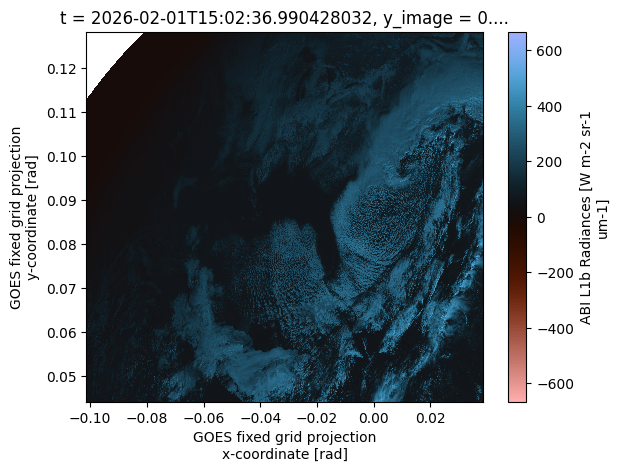

In [18]:
c01.Rad.plot(cmap='berlin_r')

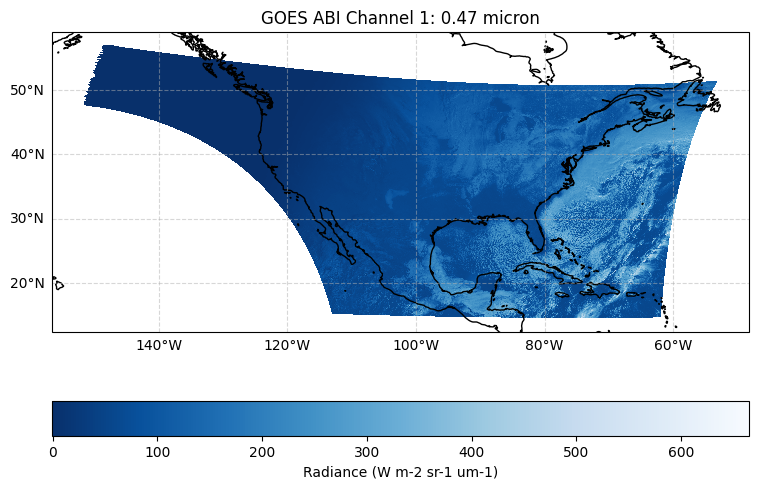

In [19]:
# Plotting as a map projection 
proj = c01.goes_imager_projection
geos = ccrs.Geostationary(
    central_longitude=float(proj.longitude_of_projection_origin),
    satellite_height=float(proj.perspective_point_height),
)

#Setting up figure
fig = plt.figure(figsize = (9,6))
ax = plt.axes(projection=ccrs.PlateCarree())

#adding the coastlines
ax.coastlines() 

#Convert scan angles [rad] to projection coordinates
h = float(c01.goes_imager_projection.perspective_point_height)
X = c01.x.values * h
Y = c01.y.values * h

#Plotting the data
pm = ax.pcolormesh(X,Y, c01.Rad, transform=geos, cmap='Blues_r')

#Adding colorbar 
plt.colorbar(pm , label=f'Radiance ({c01.Rad.units})',orientation='horizontal')

#Set latitude and longitude info
gl = ax.gridlines(draw_labels=True, linestyle = '--', alpha = 0.5)
gl.top_labels = False
gl.right_labels = False

# Adding a title
plt.title(f'GOES ABI Channel 1: {c01.band_wavelength.values[0]:.2f} micron')
plt.show()

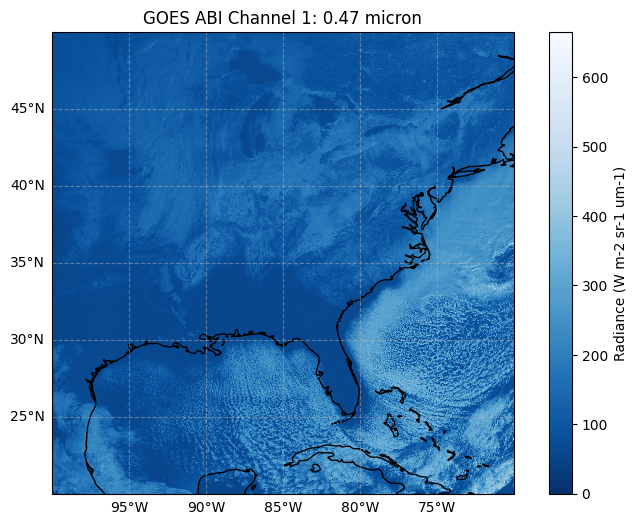

In [20]:
#Plot as a map projection focused over the southeastern US

#Set up projection using GOES file specifications
proj = c01.goes_imager_projection
geos = ccrs.Geostationary(
    central_longitude=float(proj.longitude_of_projection_origin),
    satellite_height=float(proj.perspective_point_height),
)

#Set up plot axes
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()

#Convert scan angles [rad] to projection coords [m]
h = float(c01.goes_imager_projection.perspective_point_height)
X = c01.x.values * h
Y = c01.y.values * h

#Plot the data
pm = ax.pcolormesh(
    X, Y, c01.Rad,
    transform=geos,
    cmap='Blues_r'
)

plt.colorbar(pm,label=f'Radiance ({c01.Rad.units})')

#Set latitude and longitude information
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_extent([-100, -70, 20, 50], crs=ccrs.PlateCarree())

#Show plot with informative title
plt.title(f'GOES ABI Channel 1: {c01.band_wavelength.values[0]:.2f} micron')
plt.show()

# Loading in other channels 

In [21]:
#Channel C02, red 640 nm, note this one channel is nominal 500 m resolution instead of 1 km
c02_files = [f for f in files if "C02" in f]
c02 = xr.open_dataset(fs.open(c02_files[0]))

In [22]:
#Channel C03, near IR 860 nm ("Veggie" for green proxy)
c03_files = [f for f in files if "C03" in f]
c03 = xr.open_dataset(fs.open(c03_files[0]))

In [23]:
#Channel C05, 1.6 micron for cloud microphysics
c05_files = [f for f in files if "C05" in f]
c05 = xr.open_dataset(fs.open(c05_files[0]))

In [24]:
#Channel C09, 6.9 micron for mid-level water vapor
c09_files = [f for f in files if "C09" in f]
c09 = xr.open_dataset(fs.open(c09_files[0]))

In [25]:
#Channel C13, 10.3 micron for clean IR window
c13_files = [f for f in files if "C13" in f]
c13 = xr.open_dataset(fs.open(c13_files[0]))

# Part 1 "True" and "false" RGB color images 

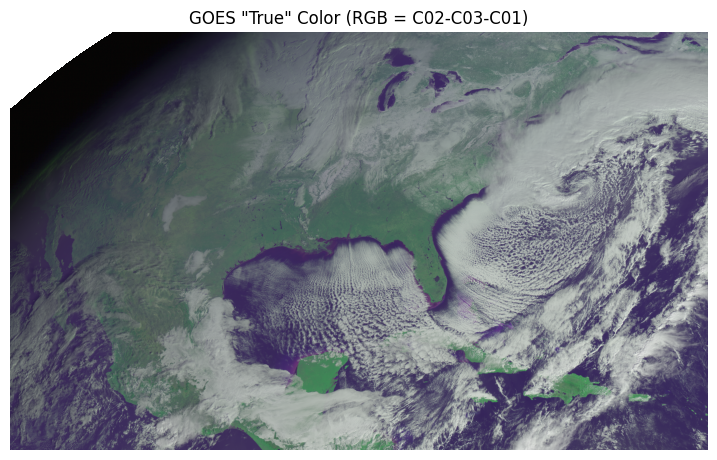

In [33]:
'''
True(ish) color RGB
'''

# Step 1 get the reflectance #
R = c02.Rad.values[::2, ::2] * c02.kappa0.values  # red; need to subset to 1 km resolution
G = c03.Rad.values * c03.kappa0.values  # veggie (green proxy)
B = c01.Rad.values * c01.kappa0.values # blue; can use 1 km data

# Step 2 - clip to a reasonable range
R = np.clip(R, 0, 1)
G = np.clip(G, 0, 1)
B = np.clip(B, 0, 1)

#Step 3 - Apply a gamma correction to make the image easier to see (brighter)
gamma = 2.4 
R = R ** (1/gamma)
G = G ** (1/gamma)
B = B ** (1/gamma)

#Step 4 - Stack into an RGB image
rgb = np.dstack([R, G, B])

# Step 5 - plotting the image
plt.figure(figsize=(9,6))
plt.imshow(rgb)
plt.axis('off')
plt.title('GOES "True" Color (RGB = C02-C03-C01)')
plt.show()

In [ ]:
'''
False color RGB
'''

# Step 1 - Get the reflectance
R = c05.Rad.values * c05.kappa0.values # 1.6 
G = c09.Rad.values * c09.kappa0.values # 6.9 
B = c01.Rad.values[::2, ::2] * c01.kappa0.values # 4.7, downsample to match 2km resolution 

print("R shape:", R.shape)
print("G shape:", G.shape)
print("B shape:", B.shape) 

# Step 2 - Clip to a resonable range
R = np.clip(R, 0, 1)
G = np.clip(G, 0, 1)
B = np.clip(B, 0, 1)

#Step 3 - apply a gamma correction to make the image easier to see (brighter)
gamma = 2.4
R = R ** (1/gamma)
G = G ** (1/gamma)
B = B ** (1/gamma)

# Step 4 - Stack into an RGB image
rgb = np.dstack([R, G, B])

# Step 5 - Plotting the image
plt.figure(figsize=(9,6))
plt.imshow(rgb)
plt.axis('off')
plt.title('GOES False Color Cloud Phase Blend (RGB = C05-C03-C01)')
plt.show()


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 3000 and the array at index 1 has size 1500